In [23]:
import os
import cv2
import dlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from imutils import face_utils
from sklearn.metrics import roc_curve, auc

# Import your geometry function
import sys
BASE_PATH = os.path.expanduser("~/100xDevs/personality/Personality-Classifier")
sys.path.append(BASE_PATH)

from src.feature_extraction.geometric_features import extract_face_shape_ratio

In [25]:
IMAGE_FOLDER = os.path.join(
    BASE_PATH,
    "data/raw/ZipCeleb/img_align_celeba/img_align_celeba"
)

ATTR_PATH = os.path.join(
    BASE_PATH,
    "data/raw/ZipCeleb/list_attr_celeba.csv"
)

PREDICTOR_PATH = os.path.join(
    BASE_PATH,
    "models/landmark_model/shape_predictor_68_face_landmarks.dat"
)

print("Image folder:", IMAGE_FOLDER)
print("Attribute file:", ATTR_PATH)

Image folder: /home/yeezy/100xDevs/personality/Personality-Classifier/data/raw/ZipCeleb/img_align_celeba/img_align_celeba
Attribute file: /home/yeezy/100xDevs/personality/Personality-Classifier/data/raw/ZipCeleb/list_attr_celeba.csv


In [26]:
df = pd.read_csv(ATTR_PATH)

print(df.columns)
print("Total samples:", len(df))

TARGET_COLUMN = "Oval_Face"

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young'],
      dtype='object')
Total samples: 202599


In [27]:
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PREDICTOR_PATH)

In [30]:
ratios = []
labels = []

sample_df = df.sample(1000, random_state=15)

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):

    image_name = row["image_id"]
    label = int(row[TARGET_COLUMN])

    image_path = os.path.join(IMAGE_FOLDER, image_name)
    image = cv2.imread(image_path)

    if image is None:
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    rects = detector(gray, 1)

    if len(rects) != 1:
        continue

    shape = predictor(gray, rects[0])
    shape = face_utils.shape_to_np(shape)

    ratio = extract_face_shape_ratio(shape)

    if ratio is None:
        continue

    ratios.append(ratio)
    labels.append(1 if label == 1 else 0)

100%|██████████| 1000/1000 [00:31<00:00, 31.63it/s]


In [31]:
ratios = np.array(ratios)
labels = np.array(labels)

print("Collected samples:", len(ratios))
print("Min ratio:", np.min(ratios))
print("Max ratio:", np.max(ratios))

Collected samples: 968
Min ratio: 0.8014415865776094
Max ratio: 1.358219763329084


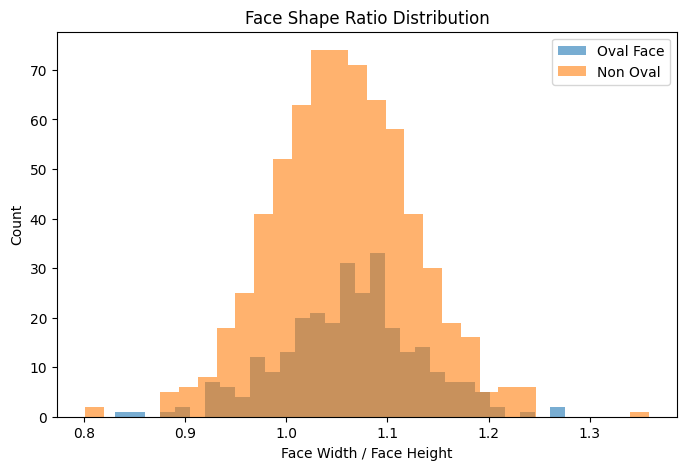

In [32]:
oval = ratios[labels == 1]
non_oval = ratios[labels == 0]

plt.figure(figsize=(8,5))
plt.hist(oval, bins=30, alpha=0.6, label="Oval Face")
plt.hist(non_oval, bins=30, alpha=0.6, label="Non Oval")
plt.legend()
plt.title("Face Shape Ratio Distribution")
plt.xlabel("Face Width / Face Height")
plt.ylabel("Count")
plt.show()

In [33]:
mean_oval = np.mean(oval)
mean_non = np.mean(non_oval)

threshold_mean = (mean_oval + mean_non) / 2

print("Mean Oval:", mean_oval)
print("Mean Non-Oval:", mean_non)
print("Mean-Based Threshold:", threshold_mean)

Mean Oval: 1.0624058577500257
Mean Non-Oval: 1.0561614844832905
Mean-Based Threshold: 1.059283671116658


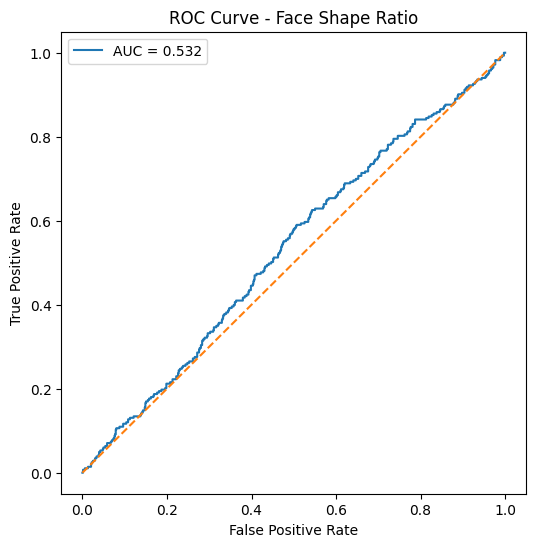

In [34]:
fpr, tpr, thresholds = roc_curve(labels, ratios)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Face Shape Ratio")
plt.legend()
plt.show()

In [35]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold (ROC-based):", optimal_threshold)

Optimal Threshold (ROC-based): 1.0534389946392122
